In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import json
import os

In [2]:
raw_files = ["kariyer.jsonl", "techcareer.jsonl", "youthall.jsonl", "indeed.jsonl", "linkedin.jsonl"]
raw_data = []

for file in raw_files:
    path = f"../data/raw/{file}"
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    raw_data.append(json.loads(line))

df_raw = pd.DataFrame(raw_data)
print(f"Total Number of Raw Listings: {len(df_raw)}")

Total Number of Raw Listings: 3257


In [3]:
df_raw.shape

(3257, 12)

In [4]:
df_raw.head()

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Withdrawal_Date,Required_Skills,Posting_Type
0,Kariyer.net,veri bilimi,AR-GE Analitik Geliştirme Uzmanı,Vem İlaç San. ve Tic. A.Ş.,Kırklareli\nİş Yerinde,Not specified,"VEM İlaç, merkezi İstanbul’da bulunan, %100 ye...",https://www.kariyer.net/is-ilani/vem-ilac-san-...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
1,Kariyer.net,veri bilimi,Yapay Zeka (Aı) Proje Uzmanı,Arıkan Mağazacılık,İstanbul\nİş Yerinde,Not specified,Arıkan Group olarak portföyümüzde var olan her...,https://www.kariyer.net/is-ilani/arikan-magaza...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
2,Kariyer.net,veri bilimi,Veri Yönetimi ve Analitiği Koordinatörü,Lokman Hekim Sağlık Grubu,Ankara\nİş Yerinde,Not specified,Lokman Hekim Üniversitesi Araştırma Dekanlığı ...,https://www.kariyer.net/is-ilani/lokman-hekim-...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
3,Kariyer.net,veri bilimi,Bilgi İşlem Uzmanı,Akasya Çocuk Dünyası A.Ş.,İstanbul(Asya)\nİş Yerinde,Not specified,"Biz KidZania İstanbul’da, “eğlenerek öğrenme” ...",https://www.kariyer.net/is-ilani/akasya-cocuk-...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
4,Kariyer.net,veri bilimi,Sürdürülebilirlik Ofisi Uzmanı,İzmir Ekonomi Üniversitesi,İzmir\nİş Yerinde,Not specified,İzmir Ekonomi Üniversitesi Sürdürülebilirlik O...,https://www.kariyer.net/is-ilani/izmir-ekonomi...,"data:image/svg+xml;charset=UTF-8,%3Csvg%20widt...",2026-07-19,NaN,NaN


In [5]:
df_raw.tail()

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Withdrawal_Date,Required_Skills,Posting_Type
3252,LinkedIn,siber güvenlik,Security Engineer (Cloud & AI Focus),Bayzat,Türkiye,Not specified,Who We Are\n\nBayzat is at the forefront of tr...,https://tr.linkedin.com/jobs/view/security-eng...,https://media.licdn.com/dms/image/v2/D4D0BAQF_...,2026-07-31,NaN,NaN
3253,LinkedIn,siber güvenlik,Cyber Security Consultant- Presales,Vodafone,Greater Istanbul,Not specified,"Join Us\n\nAt Vodafone, we’re not just shaping...",https://tr.linkedin.com/jobs/view/cyber-securi...,https://media.licdn.com/dms/image/v2/C560BAQGA...,2026-07-31,NaN,NaN
3254,LinkedIn,siber güvenlik,IT Infrastructure and Cyber Security Operation...,Nobel Ilac A.S,"Ümraniye, Istanbul, Türkiye",Not specified,What is the Summary of This Position?\n\n\n\n\...,https://tr.linkedin.com/jobs/view/it-infrastru...,https://media.licdn.com/dms/image/v2/D4D0BAQF3...,2026-07-31,NaN,NaN
3255,LinkedIn,siber güvenlik,IT Compliance Analyst,Shell,Greater Istanbul,Not specified,Job Purpose\n\nEnsure that Security controls f...,https://tr.linkedin.com/jobs/view/it-complianc...,https://media.licdn.com/dms/image/v2/C4D0BAQGN...,2026-07-31,NaN,NaN
3256,LinkedIn,qa engineer,QA Engineer (Manual Testing Focus),CBOT,"Istanbul, Türkiye",Not specified,Qualifications\n\n\n\n\nBachelor's or Master's...,https://tr.linkedin.com/jobs/view/qa-engineer-...,https://media.licdn.com/dms/image/v2/C4E0BAQHp...,2026-07-31,NaN,NaN


In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3257 entries, 0 to 3256
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Platform          3257 non-null   str  
 1   Search_Keyword    2964 non-null   str  
 2   Job_Title         3257 non-null   str  
 3   Company           3257 non-null   str  
 4   Location_Details  3257 non-null   str  
 5   Job_Type          3157 non-null   str  
 6   Job_Description   3257 non-null   str  
 7   Job_Link          3257 non-null   str  
 8   Logo_Link         3257 non-null   str  
 9   Withdrawal_Date   3257 non-null   str  
 10  Required_Skills   193 non-null    str  
 11  Posting_Type      100 non-null    str  
dtypes: str(12)
memory usage: 10.8 MB


In [7]:
df_raw.describe(include='all').T

,count,unique,top,freq
Platform,3257,5,LinkedIn,1359
Search_Keyword,2964,22,yapay zeka,363
Job_Title,3257,2201,Elektrik Elektronik Mühendisi,42
Company,3257,1665,"EPAM Systems, Inc.",62
Location_Details,3257,301,İstanbul,468
Job_Type,3157,51,Not specified,2122
Job_Description,3257,2886,Description could not be retrieved,183
Job_Link,3257,3257,https://www.kariyer.net/is-ilani/vem-ilac-san-...,1
Logo_Link,3257,949,No Logo,1016
Withdrawal_Date,3257,4,2026-07-19,2309


In [8]:
df_raw.duplicated().sum()

np.int64(0)

In [9]:
df_raw.isnull().sum()

Platform               0
Search_Keyword       293
Job_Title              0
Company                0
Location_Details       0
Job_Type             100
Job_Description        0
Job_Link               0
Logo_Link              0
Withdrawal_Date        0
Required_Skills     3064
Posting_Type        3157
dtype: int64

In [10]:
df_raw['Job_Type'].value_counts()

Job_Type
Not specified                                 2122
                                               567
Tam zamanlı                                    192
İş Yerinde                                     145
Asya / Türkiye                                  29
Tam zamanlı +1                                  20
Hibrit                                          15
Yarı zamanlı +1                                  8
Yarı zamanlı                                     6
Kontratlı                                        4
Uzaktan                                          3
₺30.000 - ₺500.000/ay                            2
₺35.000 - ₺45.000/ay                             2
En az ₺45.000/ay - Tam zamanlı                   2
Tam zamanlı +2                                   2
En az ₺30.000/ay - Tam zamanlı                   2
Staj                                             2
Avr. / Türkiye                                   1
₺580.000 - ₺1.130.000/yıl - Tam zamanlı +1       1
₺35.000 - ₺60.000/ay -

In [11]:
df_raw['Required_Skills'].value_counts()

Required_Skills
Analitik Düşünme                                                                                                                                  5
Takım Çalışmasına Ya, Problem Çözme, Detaylara Dikkat, Kodlama                                                                                    2
Yapay Zeka, Pazarlama, Dijital Pazarlama, Dijital Video, Video Kurgu, Video Düzenleme                                                             2
sql, analitik düşünme, analiz yapma, yazılım, veri raporlama, ekip çalışması, sorun çözme, proje planlama, ms office, üretim                      2
SAP, SAP Abap                                                                                                                                     2
                                                                                                                                                 ..
Analitik Düşünme, Problem Çözme, Takım Çalışmasına Ya, Etkili İletişim, Sunum Becerileri, Power 

In [12]:
df_raw['Posting_Type'].value_counts()        

Posting_Type
Talent Program / Internship    91
Job Posting                     9
Name: count, dtype: int64

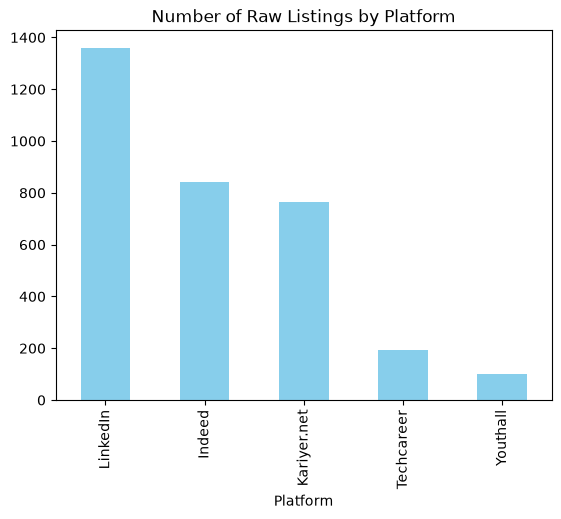

In [13]:
df_raw['Platform'].value_counts().plot(kind='bar', color='skyblue', title='Number of Raw Listings by Platform')
plt.show()

In [14]:
df_clean = pd.read_csv("../data/processed/cleaned_data.csv")
print(f"Number of Cleaned Ads: {len(df_clean)}")

Number of Cleaned Ads: 2537


In [15]:
df_clean.sample(n=5)

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Required_Skills,first_seen,last_seen,Work_Model,Experience_Level
221,Indeed,.net,Deneyimli Yazılım Mühendisi,Arne Yazılım,İstanbul,Full-time,2020 yılında M+ Group ile güçlerini birleştire...,https://tr.indeed.com/viewjob?jk=ef4d4544c08f963c,No Logo,Not specified,2026-07-28,2026-07-28,On-site,Not specified
2040,Kariyer.net,yapay zeka,E -Ticaret Uzmanı,Fitbody Türkiye,İstanbul,Full-time,E-Ticaret Uzmanı – Shopify & Pazaryeri Yönetim...,https://www.kariyer.net/is-ilani/fitbody-turki...,"data:image/svg+xml;charset=UTF-8,%3Csvg%20widt...","excel, html, css",2026-07-19,2026-07-19,On-site,Mid-Level
2387,Indeed,machine learning,Senior Computer Vision Engineer,Wide and Wise,İstanbul,Full-time,About the job\n\nWe are looking for a Senior C...,https://tr.indeed.com/viewjob?jk=40f1ae0028ab03f4,No Logo,"python, machine learning, deep learning, data ...",2026-07-19,2026-07-19,On-site,Senior
150,Kariyer.net,data engineer,Data Analyst/ Researcher\naccessible,TURBOARD (E-Kalite),Ankara,Full-time,This job posting is intended for candidates wi...,https://www.kariyer.net/is-ilani/turboard-e-ka...,No Logo,Not specified,2026-07-29,2026-07-29,On-site,Not specified
2108,Indeed,python,Retail & Micro SME Credit Analytics Manager,BNP Paribas,İstanbul,Full-time,Key Responsibilities\n\nContribute end to end ...,https://tr.indeed.com/viewjob?jk=8dc92cfdedb2cbf8,No Logo,"python, sql",2026-07-19,2026-07-19,On-site,Lead/Manager


In [16]:
df_clean['Work_Model'].value_counts()

Work_Model
On-site    2476
Hybrid       55
Remote        6
Name: count, dtype: int64

In [17]:
df_clean['Job_Type'].value_counts()

Job_Type
Full-time    2407
Intern         81
Freelance      28
Part-time      21
Name: count, dtype: int64

In [18]:
df_clean['Experience_Level'].value_counts()

Experience_Level
Lead/Manager     868
Not specified    728
Senior           636
Mid-Level        189
Junior           116
Name: count, dtype: int64

In [19]:
df_clean['Location_Details']


0       İstanbul
1       İstanbul
2       İstanbul
3       İstanbul
4       İstanbul
          ...   
2532    İstanbul
2533    İstanbul
2534     Antalya
2535    İstanbul
2536    İstanbul
Name: Location_Details, Length: 2537, dtype: str

In [20]:
df_clean.columns

Index(['Platform', 'Search_Keyword', 'Job_Title', 'Company',
       'Location_Details', 'Job_Type', 'Job_Description', 'Job_Link',
       'Logo_Link', 'Required_Skills', 'first_seen', 'last_seen', 'Work_Model',
       'Experience_Level'],
      dtype='str')

In [21]:
df_clean['Experience_Level'].value_counts()

Experience_Level
Lead/Manager     868
Not specified    728
Senior           636
Mid-Level        189
Junior           116
Name: count, dtype: int64

In [22]:
df_clean['Job_Title'].value_counts()

Job_Title
DevOps Engineer                             19
Software Engineer                           19
Yazılım Mühendisi                           16
Backend Developer                           15
Data Analyst                                14
                                            ..
Lead Frontend Yazılım Mühendisi              1
Sistem Mühendisi / Altyapı Destek Uzmanı     1
Kıdemli UX/UI Tasarımcısı                    1
Project Engineers - Full Stack Developer     1
Hasar Yönetimi Uzmanı                        1
Name: count, Length: 1949, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_12328\503496978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_companies.index, x=top_companies.values, palette="viridis")


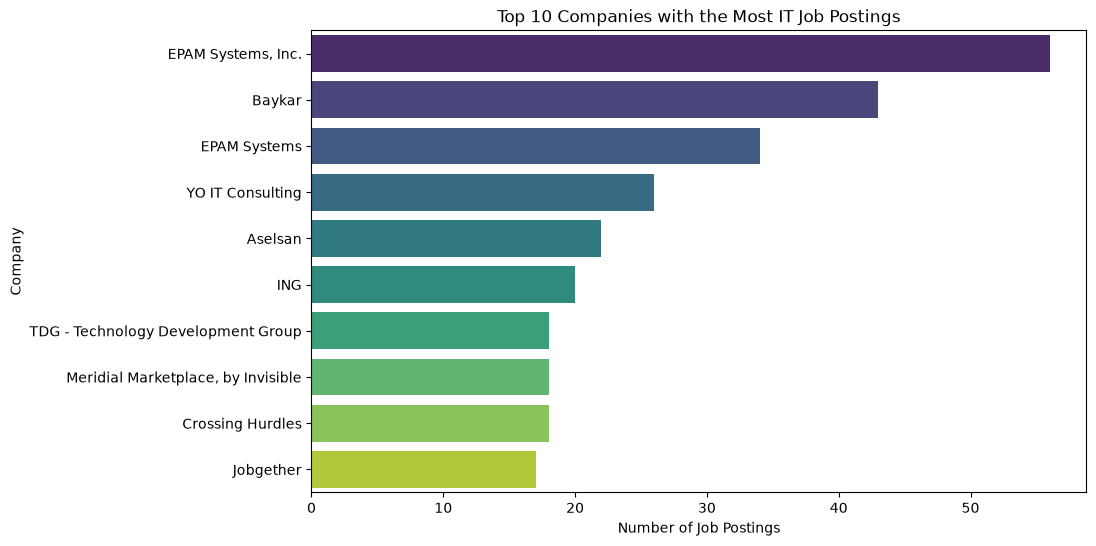

In [23]:
plt.figure(figsize=(10, 6))
top_companies = df_clean['Company'].value_counts().head(10)
sns.barplot(y=top_companies.index, x=top_companies.values, palette="viridis")
plt.title("Top 10 Companies with the Most IT Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.show()

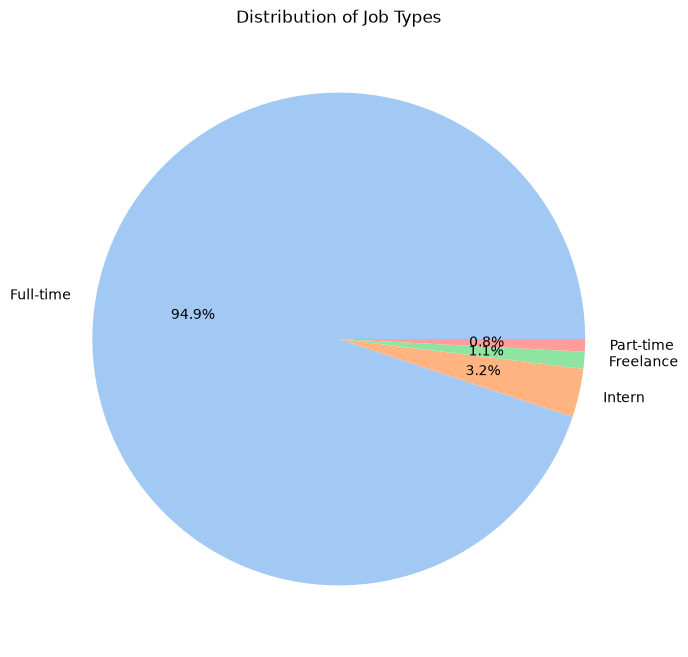

In [24]:
plt.figure(figsize=(8, 8))
job_types = df_clean['Job_Type'].value_counts()
plt.pie(job_types.values, labels=job_types.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Distribution of Job Types")
plt.show()

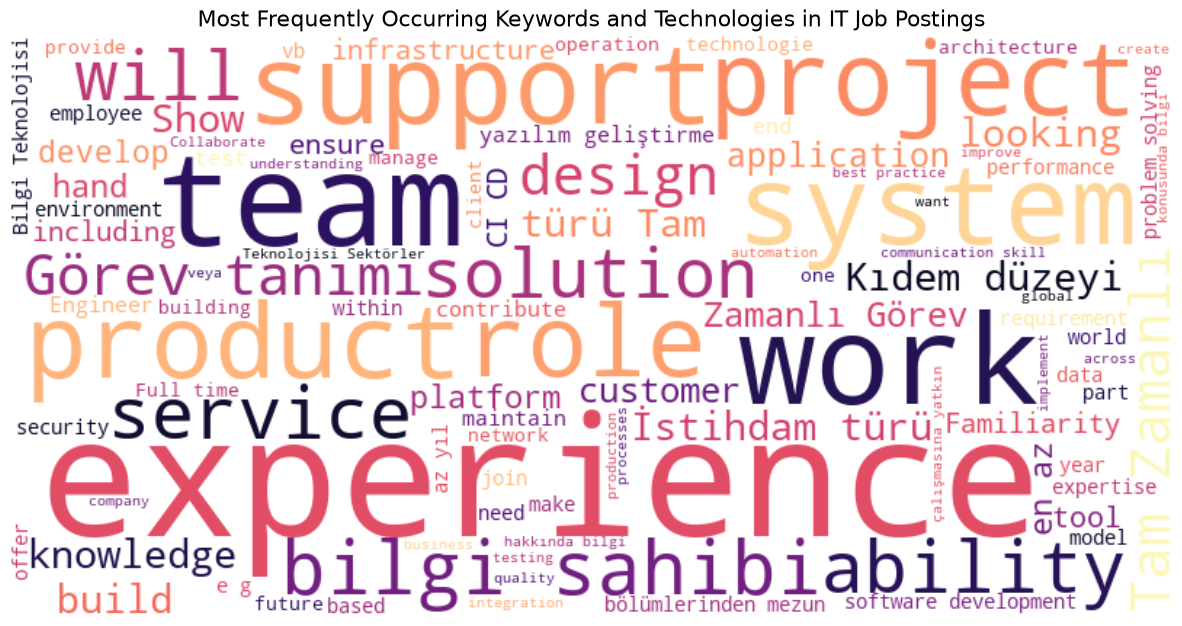

In [25]:
text = " ".join(desc for desc in df_clean['Job_Description'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="magma", max_words=100).generate(text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequently Occurring Keywords and Technologies in IT Job Postings", fontsize=16)
plt.show()

## Model3 
### Spatial Separation Map with UMAP

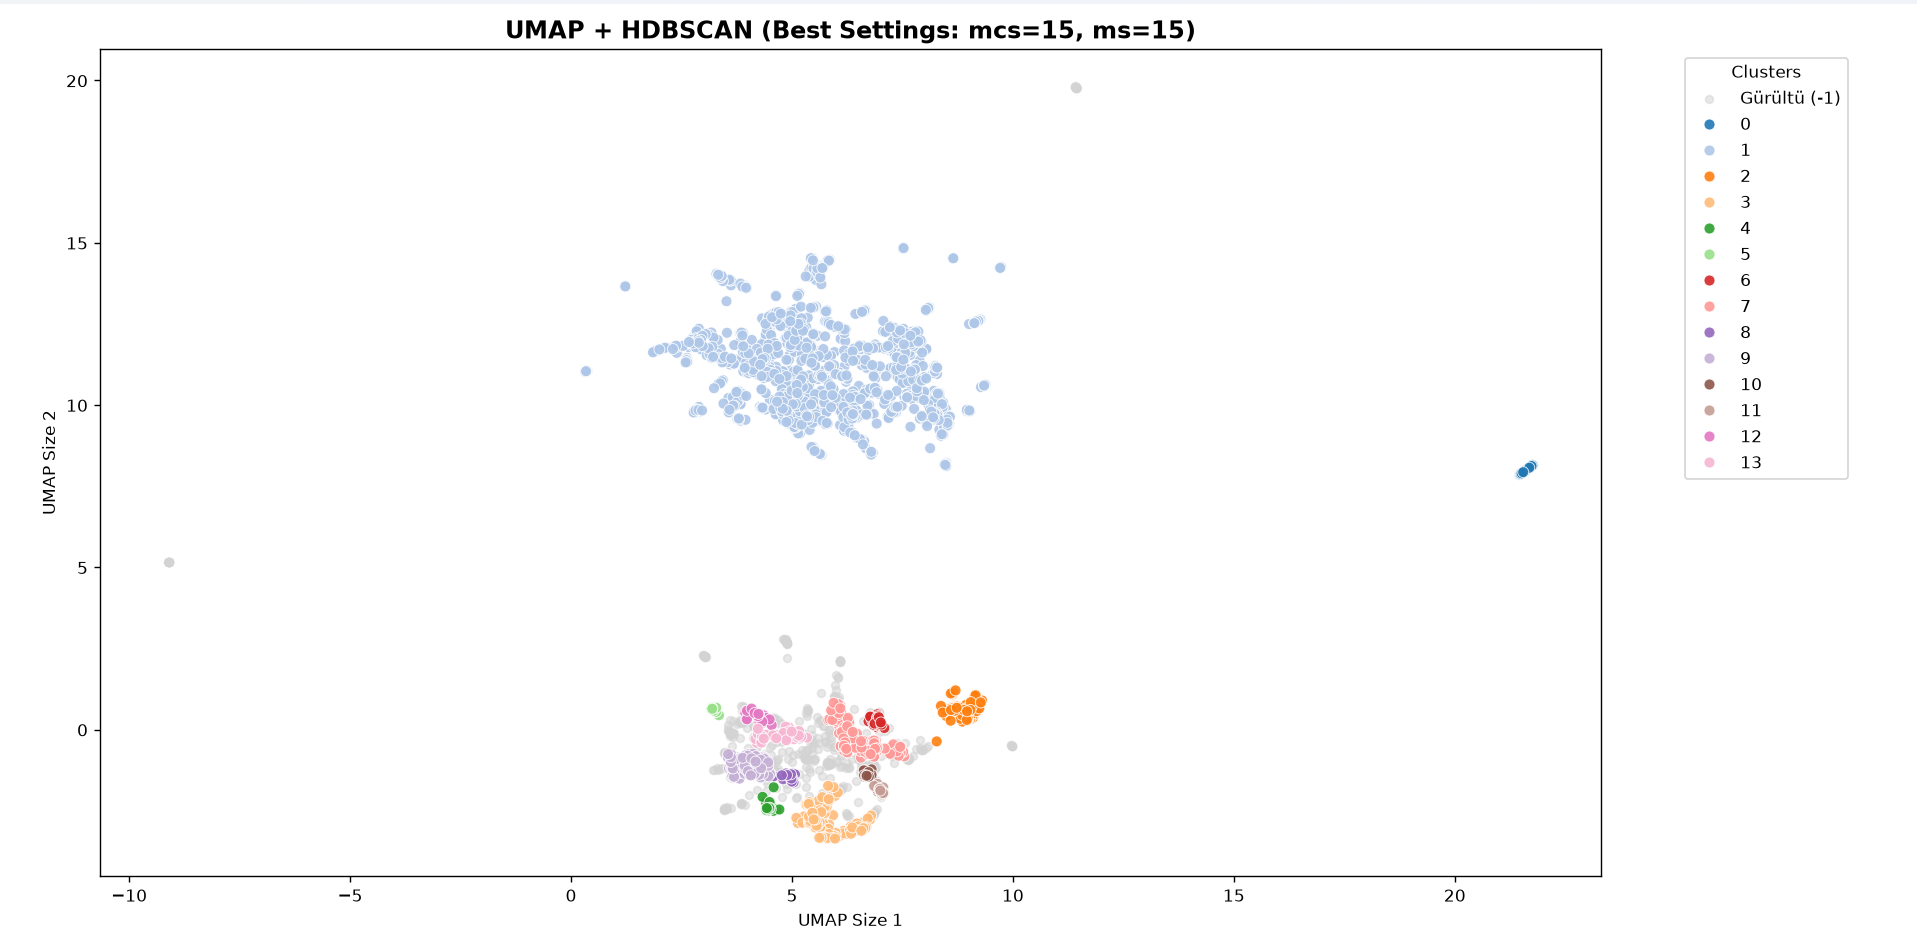

In [26]:
df_domain = pd.read_csv("../data/processed/labeled_domain_data.csv")
print(len(df_domain))

2068


In [27]:
df_domain.columns

Index(['Platform', 'Search_Keyword', 'Job_Title', 'Company',
       'Location_Details', 'Job_Type', 'Job_Description', 'Job_Link',
       'Logo_Link', 'Required_Skills', 'first_seen', 'last_seen', 'Work_Model',
       'Experience_Level', 'Job_Domain'],
      dtype='str')

In [28]:
df_domain.sample(5)

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Required_Skills,first_seen,last_seen,Work_Model,Experience_Level,Job_Domain
1885,Indeed,yapay zeka,Yazılım Geliştirici (E-Ticaret Ve Entegrasyon),Depoba Tekstil Ürünleri,İstanbul,Full-time,YAZILIM GELİŞTİRİCİ (E-Ticaret ve Entegrasyon)...,https://tr.indeed.com/viewjob?jk=9c52b9789d883775,No Logo,"python, node, mysql, yapay zeka",2026-07-19,2026-07-19,On-site,Not specified,Data & AI
918,LinkedIn,.net,Ticari Kredi Risk Stratejileri Uzman/Uzman Yar...,Yapı Kredi,İstanbul,Full-time,"Yapı Kredi olarak 1944’ten beri ilklerin, yeni...",https://tr.linkedin.com/jobs/view/ticari-kredi...,https://media.licdn.com/dms/image/v2/D4D0BAQFo...,"sql, excel",2026-07-19,2026-07-19,On-site,Not specified,Cybersecurity
1492,Techcareer,NaN,Yazılım Geliştirme Elemanı,YFA Furkan Altınkaynak Yayıncılık Sinema Film ...,Ankara,Full-time,Mid - Senior Full-Stack Developer (.NET 8 & Ne...,https://www.techcareer.net/jobs/detail/yazlm-g...,https://www.techcareer.net/_next/image?url=htt...,"Veri Tabanı Yönetimi, Wolverine, Cqrs, JWT, gR...",2026-07-19,2026-07-19,On-site,Senior,DevOps & Cloud
395,Indeed,frontend,Software Engineer II with Accounting Experience,Sezzle,İstanbul,Full-time,"The salary range for this role is $2,800 - $6,...",https://tr.indeed.com/viewjob?jk=dae325b4ff4b7c64,No Logo,"python, java, typescript, react, mysql, postgr...",2026-07-28,2026-07-28,On-site,Lead/Manager,DevOps & Cloud
1375,Techcareer,NaN,Bilgi İşlem Sorumlusu,GL Events - Serenas Group,Ankara,Full-time,İŞ TANIMI\n\nÜniversitelerin veya yüksekokulla...,https://www.techcareer.net/jobs/detail/bilgi-i...,https://www.techcareer.net/_next/image?url=htt...,"Windows, Mac OS, Network, Switch, Access Point...",2026-07-19,2026-07-19,On-site,Not specified,"System, Network & IT Ops"


In [29]:
df_pred = pd.read_csv("../data/processed/predicted_data.csv")
print(len(df_pred))

2537


In [30]:
df_pred.sample(5)

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Required_Skills,first_seen,last_seen,Work_Model,Experience_Level,Job_Domain,Cluster_ID,Cluster_X,Cluster_Y
2510,Indeed,software developer,Part Time Working Student (Software Test Engin...,Siemens,İstanbul,Part-time,We are the catalyst for the industrial world’s...,https://tr.indeed.com/viewjob?jk=3ae0744ab7f56d6c,No Logo,"python, linux, html",2026-07-19,2026-07-19,On-site,Lead/Manager,QA & Testing,1,9.4053,10.6342
792,LinkedIn,machine learning,Business Owners - Freelance AI Trainer Project,"Meridial Marketplace, by Invisible",Not specified,Freelance,Project Overview\n\nWe are sourcing independen...,https://tr.linkedin.com/jobs/view/business-own...,https://media.licdn.com/dms/image/v2/D4D0BAQHx...,Not specified,2026-07-19,2026-07-19,On-site,Lead/Manager,Data & AI,1,2.9469,9.9173
221,Indeed,.net,Deneyimli Yazılım Mühendisi,Arne Yazılım,İstanbul,Full-time,2020 yılında M+ Group ile güçlerini birleştire...,https://tr.indeed.com/viewjob?jk=ef4d4544c08f963c,No Logo,Not specified,2026-07-28,2026-07-28,On-site,Junior,General Software,2,8.2839,0.6324
229,Indeed,.net,Özel Eğitim Uzmanı,Orange County Hotels,Antalya,Full-time,Orange County Hotels bünyesinde istihdam etmek...,https://tr.indeed.com/viewjob?jk=11cef811e65ab6d7,No Logo,Not specified,2026-07-28,2026-07-28,On-site,Mid-Level,Data & AI,-1,8.0133,-0.6773
2271,Indeed,java,"Engineering Manager, SAP CAP Java","EPAM Systems, Inc.",Not specified,Full-time,We are seeking a qualified Engineering Manager...,https://tr.indeed.com/viewjob?jk=c9fb28ca060f18a4,No Logo,"java, aws, azure, gcp, ci/cd, spring boot",2026-07-19,2026-07-19,On-site,Lead/Manager,Backend,1,2.0707,11.7280


In [32]:
df_pred['Job_Type'].value_counts()

Job_Type
Full-time    2407
Intern         81
Freelance      28
Part-time      21
Name: count, dtype: int64

In [33]:
df_pred['Work_Model'].value_counts()

Work_Model
On-site    2476
Hybrid       55
Remote        6
Name: count, dtype: int64

In [34]:
df_pred['Experience_Level'].value_counts()

Experience_Level
Lead/Manager    904
Senior          758
Junior          497
Mid-Level       378
Name: count, dtype: int64

In [35]:
df_pred['Job_Domain'].value_counts()

Job_Domain
Data & AI                      820
DevOps & Cloud                 314
General Software               275
Backend                        211
System, Network & IT Ops       183
QA & Testing                   170
Product & Business Analysis    150
Cybersecurity                  125
Full Stack                     116
Frontend                        73
Mobile                          52
Game Development                20
UI/UX & Design                  19
Database Administration          9
Name: count, dtype: int64